# Task 1 & 2: Time Series Forecasting (RNN & Deep RNN)

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# 1. Generate Synthetic Time Series Data
def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  # wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # wave 2
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)   # noise
    return series[..., np.newaxis].astype(np.float32)

n_steps = 50
series = generate_time_series(10000, n_steps + 1)
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

# 2. Deep RNN with Layer Normalization
# Layer Normalization is preferred over Batch Normalization for RNNs
model_deep_rnn = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.LayerNormalization(),
    keras.layers.SimpleRNN(20),
    keras.layers.LayerNormalization(),
    keras.layers.Dense(1)
])

model_deep_rnn.compile(loss="mse", optimizer="adam")
history = model_deep_rnn.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

print("\nTask 1 & 2: Deep RNN with LayerNorm complete.")

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.2823 - val_loss: 0.0058
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0054 - val_loss: 0.0050
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0047 - val_loss: 0.0045
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0045 - val_loss: 0.0051
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0043 - val_loss: 0.0042
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0044 - val_loss: 0.0042
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0041 - val_loss: 0.0041
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0043 - val_loss: 0.0041
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0043 - val_loss: 0.0050
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0041 - val_loss: 0.0050

Task 1 & 2: Deep RNN with LayerNorm complete.


# Task 3 ，4

1.   Train LSTM and GRU networks for the time series prediction problem from step 1.
2.   Report the results of steps 1-3 using error indicators and plot the training and testing datasets' histories.





Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - loss: 0.0795 - val_loss: 0.0266
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - loss: 0.0214 - val_loss: 0.0121
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0084 - val_loss: 0.0043
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0041 - val_loss: 0.0032
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - loss: 0.0034 - val_loss: 0.0031
Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0304 - val_loss: 0.0101
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0085 - val_loss: 0.0067
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0060 - val_loss: 0.0057
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0052 - val_loss: 0.0051
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0048 - val_loss: 0.0046


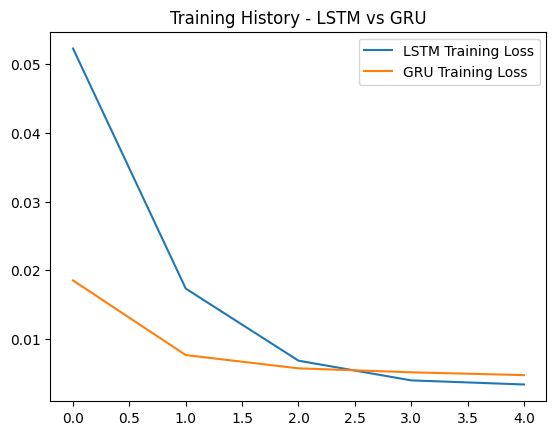

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0045
Final GRU Test MSE: 0.0044


In [2]:
# 1. Train LSTM
model_lstm = keras.models.Sequential([
    keras.layers.LSTM(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.LSTM(20),
    keras.layers.Dense(1)
])
model_lstm.compile(loss="mse", optimizer="adam")
history_lstm = model_lstm.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))

# 2. Train GRU
model_gru = keras.models.Sequential([
    keras.layers.GRU(20, input_shape=[None, 1]),
    keras.layers.Dense(1)
])
model_gru.compile(loss="mse", optimizer="adam")
history_gru = model_gru.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))

# 3. Visualization
plt.plot(history_lstm.history['loss'], label='LSTM Training Loss')
plt.plot(history_gru.history['loss'], label='GRU Training Loss')
plt.title('Training History - LSTM vs GRU')
plt.legend()
plt.show()

mse_val = model_gru.evaluate(X_test, y_test)
print(f"Final GRU Test MSE: {mse_val:.4f}")

# Task 5: Bach Music Generation

In [8]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras

# 1. Download and Extract Batch Chorales
url = "https://github.com/ageron/handson-ml2/raw/master/datasets/jsb_chorales/jsb_chorales.tgz"
path = keras.utils.get_file("jsb_chorales.tgz", url, extract=True)
datadir = path

def load_chorales(filepaths):
    return [np.genfromtxt(fp, delimiter=',', dtype=int) for fp in filepaths]

train_files = [os.path.join(datadir, f"train/chorale_{i:03d}.csv") for i in range(229)]
train_chorales = load_chorales(train_files)

# Define window_size globally so it's accessible by the model as well
window_size = 32

# 2. Preprocess Data for Music Generation
# Windowing the data: input sequence -> predict next time step
def create_dataset(chorales, batch_size=32, window_size=window_size):
    # Fix: Use output_signature to specify the shape of elements yielded by the generator
    dataset = tf.data.Dataset.from_generator(
        lambda: (c for c in chorales),
        output_signature=tf.TensorSpec(shape=(None, 4), dtype=tf.int32)
    )
    dataset = dataset.flat_map(lambda x: tf.data.Dataset.from_tensor_slices(x).window(window_size + 1, shift=1, drop_remainder=True))
    dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))
    dataset = dataset.map(lambda window: (window[:-1], window[1:]))
    return dataset.shuffle(1000).batch(batch_size).prefetch(1)

train_set = create_dataset(train_chorales)

# 3. Music Generation Model (Hybrid Conv/RNN)
model_music = keras.models.Sequential([
    # Fix: Use keras.Input as the first layer to explicitly define the model's input shape
    keras.Input(shape=(window_size, 4)), # Input shape (None, 32, 4) for (batch_size, window_size, 4)
    keras.layers.Embedding(input_dim=100, output_dim=16), # input_shape is now inferred from the Input layer
    keras.layers.Reshape([-1, 4 * 16]), # Flatten note embeddings
    keras.layers.Conv1D(32, kernel_size=2, padding="causal", activation="relu"),
    keras.layers.GRU(128, return_sequences=True),
    keras.layers.Dense(4 * 100), # 4 notes, each with 100 possible values
    keras.layers.Reshape([-1, 4, 100]),
    keras.layers.Softmax()
])

model_music.compile(loss="sparse_categorical_crossentropy", optimizer="adam")
model_music.fit(train_set, epochs=5)

print("\nTask 5: Bach-like Music Model Trained.")

Epoch 1/5
1505/1505 ━━━━━━━━━━━━━━━━━━━━ 88s 57ms/step - loss: 1.8135
Epoch 2/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1505/1505 ━━━━━━━━━━━━━━━━━━━━ 86s 57ms/step - loss: 0.7671
Epoch 3/5
1505/1505 ━━━━━━━━━━━━━━━━━━━━ 86s 57ms/step - loss: 0.6701
Epoch 4/5
1505/1505 ━━━━━━━━━━━━━━━━━━━━ 84s 56ms/step - loss: 0.6116
Epoch 5/5
1505/1505 ━━━━━━━━━━━━━━━━━━━━ 86s 57ms/step - loss: 0.5729

Task 5: Bach-like Music Model Trained.
